# Gap-fill meteo variables

</br>

# Settings

## Data settings

In [7]:
SITE_LAT = 47.478333   # CH-LAE
SITE_LON = 8.364389  # CH-LAE
TIMEZONE_OFFSET_TO_UTC_HOURS = 1  # Timezone, e.g. "1" is translated to timezone "UTC+01:00" (CET, winter time)

## Imports

In [42]:
from datetime import datetime
import importlib.metadata
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
sns.set_theme('notebook')
import diive as dv
from diive.core.plotting.timeseries import TimeSeries
from diive.core.io.files import load_parquet, save_parquet
from diive.core.plotting.heatmap_datetime import HeatmapDateTime
from diive.core.times.times import DetectFrequency
from diive.core.times.times import TimestampSanitizer
from diive.pkgs.createvar.potentialradiation import potrad
from diive.pkgs.gapfilling.xgboost_ts import XGBoostTS
from diive.pkgs.corrections.offsetcorrection import remove_relativehumidity_offset, remove_radiation_zero_offset
import warnings
from influxdb_client.client.warnings import MissingPivotFunction
warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
version_diive = importlib.metadata.version("diive")
print(f"diive version: v{version_diive}")

diive version: v0.90.0


</br>

# Load data from files

In [9]:
filename_meteo6_2004_2025 = "02_METEO6_NOT-GAPFILLED_2004-2025.parquet"
meteo6_2004_2025 = load_parquet(filepath=filename_meteo6_2004_2025)
meteo6_2004_2025

Loaded .parquet file 02_METEO6_NOT-GAPFILLED_2004-2025.parquet (0.383 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


,RH_T1_47_1,SW_IN_T1_47_1,TA_T1_47_1,LW_IN_T1_47_1,PPFD_IN_T1_47_1,PA_T1_47_1
TIMESTAMP_MIDDLE,,,,,,
2004-01-01 00:15:00,96.366667,0.0,-2.666667,NaN,NaN,NaN
2004-01-01 00:45:00,95.566667,0.0,-2.566667,NaN,NaN,NaN
2004-01-01 01:15:00,92.200000,0.0,-2.533333,NaN,NaN,NaN
2004-01-01 01:45:00,91.300000,0.0,-2.633333,NaN,NaN,NaN
2004-01-01 02:15:00,92.633333,0.0,-2.800000,NaN,NaN,NaN
...,...,...,...,...,...,...
2025-12-31 21:45:00,42.332976,0.0,-3.081644,210.420480,0.0,93.435334
2025-12-31 22:15:00,39.230344,0.0,-3.084372,210.648200,0.0,93.422110
2025-12-31 22:45:00,55.771803,0.0,-3.423939,211.147057,0.0,93.404179


</br>

# Gap-filling

## SW_IN_T1_47_1

In [10]:
VAR = "SW_IN_T1_47_1"

In [11]:
_df = pd.DataFrame()
_df[VAR] = meteo6_2004_2025[[VAR]].copy()
_df['SW_IN_POT'] = potrad(timestamp_index=_df.index, lat=SITE_LAT, lon=SITE_LON, utc_offset=1)
_df

,SW_IN_T1_47_1,SW_IN_POT
TIMESTAMP_MIDDLE,,
2004-01-01 00:15:00,0.0,0.0
2004-01-01 00:45:00,0.0,0.0
2004-01-01 01:15:00,0.0,0.0
2004-01-01 01:45:00,0.0,0.0
2004-01-01 02:15:00,0.0,0.0
...,...,...
2025-12-31 21:45:00,0.0,0.0
2025-12-31 22:15:00,0.0,0.0
2025-12-31 22:45:00,0.0,0.0


In [12]:
xgb = XGBoostTS(
    input_df=_df,
    target_col=VAR,
    perm_n_repeats=10,
    vectorize_timestamps=True,
    add_continuous_record_number=True,
    n_estimators=1000,
    random_state=42,
    early_stopping_rounds=50,
    n_jobs=-1
)


Adding new data columns ...
++ Added new columns with timestamp info: ['.YEAR', '.SEASON', '.SEASON_SIN', '.SEASON_COS', '.MONTH', '.MONTH_SIN', '.MONTH_COS', '.WEEK', '.WEEK_SIN', '.WEEK_COS', '.DOY', '.DOY_SIN', '.DOY_COS', '.HOUR', '.HOUR_SIN', '.HOUR_COS', '.YEARMONTH', '.YEARDOY', '.YEARWEEK'] 
++ Added new column .RECORDNUMBER with record numbers from 1 to 385728.


In [13]:
xgb.trainmodel(showplot_scores=False, showplot_importance=False)
xgb.report_traintest()


Training final model ...
>>> Training model <class 'xgboost.sklearn.XGBRegressor'> based on data between 2004-01-01 00:15:00 and 2025-12-31 23:15:00 ...
>>> Fitting model to training data ...
[0]	validation_0-rmse:187.59053	validation_1-rmse:187.53123
[1]	validation_0-rmse:157.45961	validation_1-rmse:157.39842
[2]	validation_0-rmse:140.17921	validation_1-rmse:140.15917
[3]	validation_0-rmse:130.63263	validation_1-rmse:130.64469
[4]	validation_0-rmse:125.57299	validation_1-rmse:125.66912
[5]	validation_0-rmse:122.83557	validation_1-rmse:123.01742
[6]	validation_0-rmse:121.37185	validation_1-rmse:121.59004
[7]	validation_0-rmse:120.35101	validation_1-rmse:120.57997
[8]	validation_0-rmse:119.77768	validation_1-rmse:120.08955
[9]	validation_0-rmse:119.12261	validation_1-rmse:119.56139
[10]	validation_0-rmse:118.47158	validation_1-rmse:118.96798
[11]	validation_0-rmse:118.12339	validation_1-rmse:118.64229
[12]	validation_0-rmse:117.70365	validation_1-rmse:118.27954
[13]	validation_0-rmse:1

In [14]:
xgb.fillgaps(showplot_scores=False, showplot_importance=False)
xgb.report_gapfilling()


Gap-filling using final model ...
>>> Using final model on all data to predict target SW_IN_T1_47_1 ...
>>> Using final model on all data to calculate permutation importance ...
>>> Calculating prediction scores based on all data predicting SW_IN_T1_47_1 ...
>>> Predicting target SW_IN_T1_47_1 where all features are available ... predicted 385728 records.
>>> Collecting results for final model ...
>>> Filling 604 missing records in target with predictions from final model ...
>>> Storing gap-filled time series in variable SW_IN_T1_47_1_gfXG ...
>>> Restoring original timestamp in results ...

Gap-filling 0 remaining missing records in SW_IN_T1_47_1_gfXG using fallback model ...
>>> Fallback model not necessary, all gaps were already filled.
>>> Combining predictions from full model and fallback model ...

GAP-FILLING RESULTS

Model scores and feature importances were calculated from high-quality predicted targets (604 values, SW_IN_T1_47_1_gfXG where flag=1) in comparison to observed 

In [15]:
observed = _df[VAR]
gapfilled = xgb.get_gapfilled_target()
meteo6_2004_2025[gapfilled.name] = gapfilled

### Plot time series

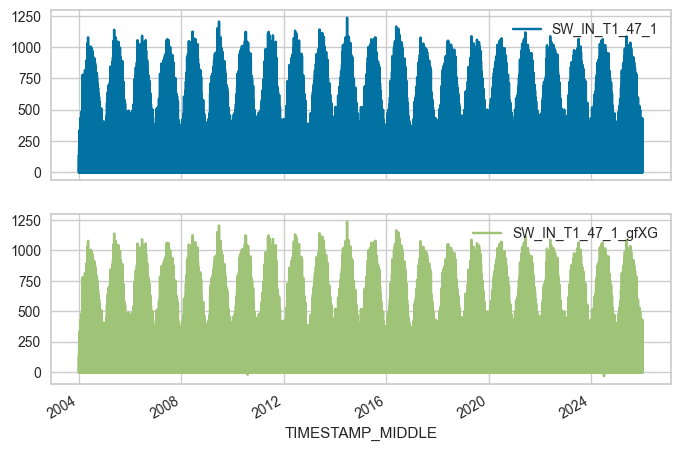

In [19]:
meteo6_2004_2025[[VAR, gapfilled.name]].plot(subplots=True, x_compat=True);

### Correction: Remove zero offset < 0 from `SW_IN_T1_47_1_gfXG`
- Additional correction needed because gap-filling introduced values < 0

In [21]:
meteo6_2004_2025[[VAR, gapfilled.name]].describe()

,SW_IN_T1_47_1,SW_IN_T1_47_1_gfXG
count,385124.000000,385728.000000
mean,142.734231,142.813149
std,237.273570,237.225006
min,0.000000,-31.253902
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,191.378154,191.481222
max,1236.201961,1236.201961


[remove_radiation_zero_offset]  running remove_radiation_zero_offset ...


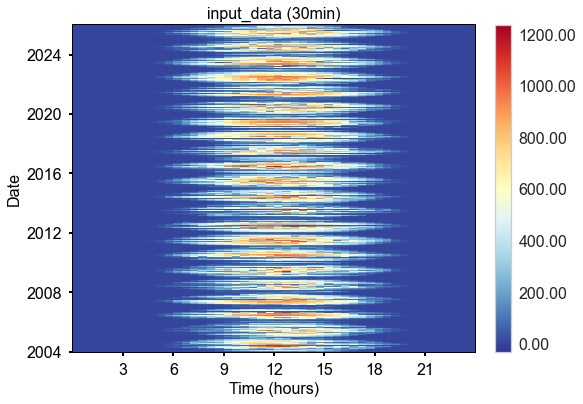

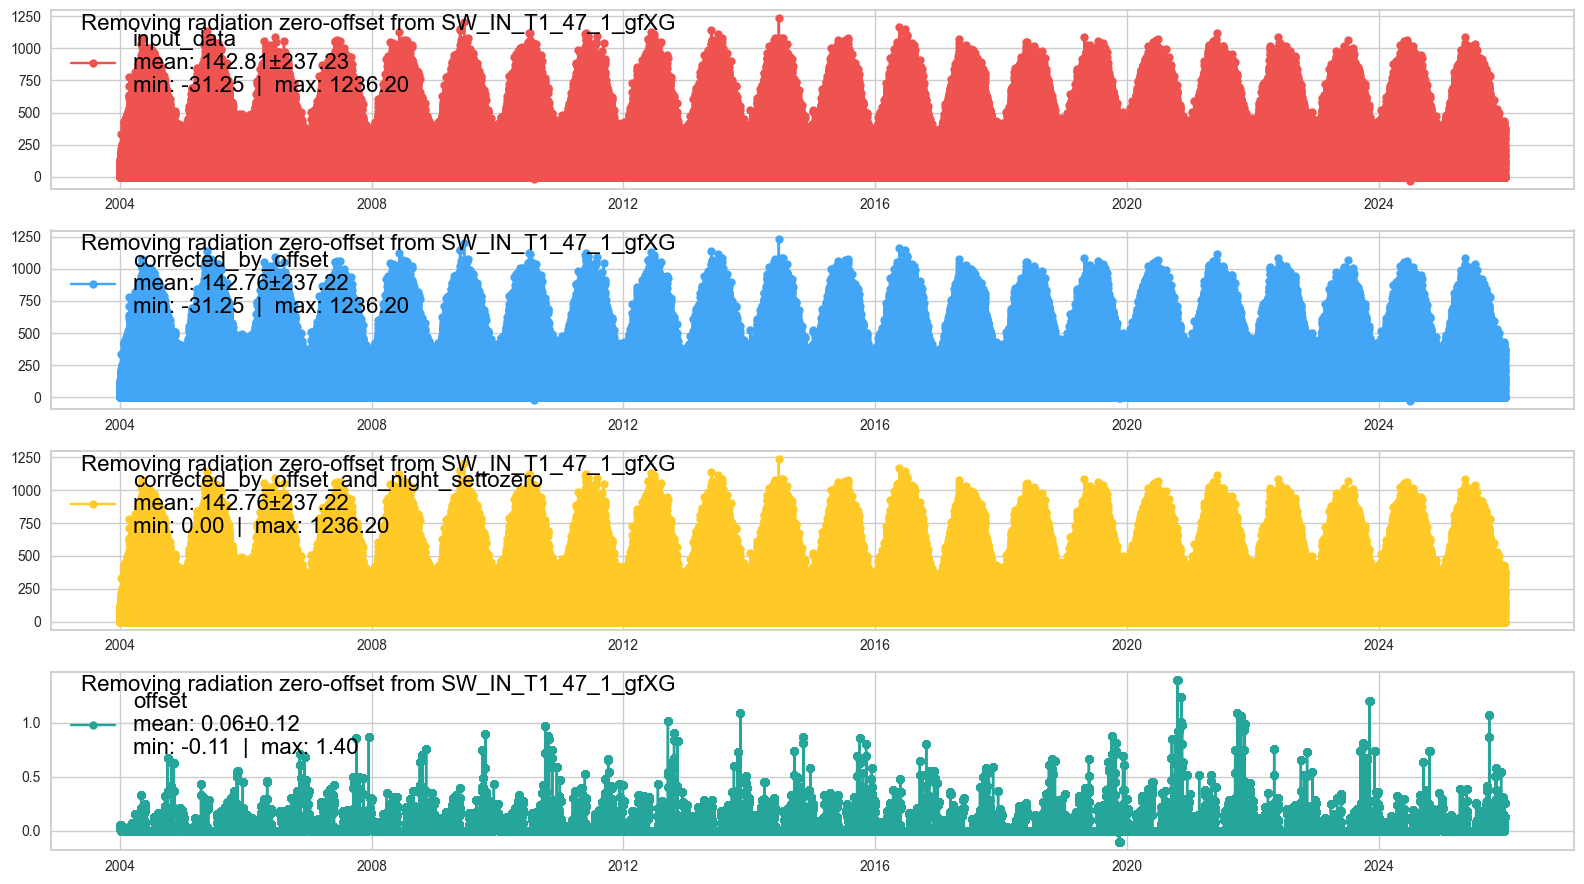

In [22]:
_swin = meteo6_2004_2025['SW_IN_T1_47_1_gfXG'].copy()
_swin_corrected = remove_radiation_zero_offset(series=_swin, lat=SITE_LAT, lon=SITE_LON, utc_offset=1, showplot=True)
meteo6_2004_2025['SW_IN_T1_47_1_gfXG'] = np.nan
meteo6_2004_2025['SW_IN_T1_47_1_gfXG'] = _swin_corrected

## TA_T1_47_1

In [23]:
VAR = "TA_T1_47_1"

In [24]:
_df = pd.DataFrame()
_df['SW_IN_T1_47_1_gfXG'] = meteo6_2004_2025['SW_IN_T1_47_1_gfXG'].copy()
_df[VAR] = meteo6_2004_2025[VAR].copy()
_df['SW_IN_POT'] = potrad(timestamp_index=_df.index, lat=SITE_LAT, lon=SITE_LON, utc_offset=1)
_df

,SW_IN_T1_47_1_gfXG,TA_T1_47_1,SW_IN_POT
TIMESTAMP_MIDDLE,,,
2004-01-01 00:15:00,0.0,-2.666667,0.0
2004-01-01 00:45:00,0.0,-2.566667,0.0
2004-01-01 01:15:00,0.0,-2.533333,0.0
2004-01-01 01:45:00,0.0,-2.633333,0.0
2004-01-01 02:15:00,0.0,-2.800000,0.0
...,...,...,...
2025-12-31 21:45:00,0.0,-3.081644,0.0
2025-12-31 22:15:00,0.0,-3.084372,0.0
2025-12-31 22:45:00,0.0,-3.423939,0.0


In [25]:
xgb = XGBoostTS(
    input_df=_df,
    target_col=VAR,
    perm_n_repeats=10,
    vectorize_timestamps=True,
    add_continuous_record_number=True,
    n_estimators=1000,
    random_state=42,
    early_stopping_rounds=50,
    n_jobs=-1
)


Adding new data columns ...
++ Added new columns with timestamp info: ['.YEAR', '.SEASON', '.SEASON_SIN', '.SEASON_COS', '.MONTH', '.MONTH_SIN', '.MONTH_COS', '.WEEK', '.WEEK_SIN', '.WEEK_COS', '.DOY', '.DOY_SIN', '.DOY_COS', '.HOUR', '.HOUR_SIN', '.HOUR_COS', '.YEARMONTH', '.YEARDOY', '.YEARWEEK'] 
++ Added new column .RECORDNUMBER with record numbers from 1 to 385728.


In [26]:
xgb.trainmodel(showplot_scores=False, showplot_importance=False)
xgb.report_traintest()


Training final model ...
>>> Training model <class 'xgboost.sklearn.XGBRegressor'> based on data between 2004-01-01 00:15:00 and 2025-12-31 23:15:00 ...
>>> Fitting model to training data ...
[0]	validation_0-rmse:6.34590	validation_1-rmse:6.32448
[1]	validation_0-rmse:5.30180	validation_1-rmse:5.28524
[2]	validation_0-rmse:4.67651	validation_1-rmse:4.66631
[3]	validation_0-rmse:4.30211	validation_1-rmse:4.29436
[4]	validation_0-rmse:4.08267	validation_1-rmse:4.07851
[5]	validation_0-rmse:3.93168	validation_1-rmse:3.92941
[6]	validation_0-rmse:3.84114	validation_1-rmse:3.84194
[7]	validation_0-rmse:3.75183	validation_1-rmse:3.75355
[8]	validation_0-rmse:3.70412	validation_1-rmse:3.70961
[9]	validation_0-rmse:3.66724	validation_1-rmse:3.67398
[10]	validation_0-rmse:3.61345	validation_1-rmse:3.61971
[11]	validation_0-rmse:3.57087	validation_1-rmse:3.57753
[12]	validation_0-rmse:3.54038	validation_1-rmse:3.54879
[13]	validation_0-rmse:3.51579	validation_1-rmse:3.52521
[14]	validation_0-r

In [27]:
xgb.fillgaps(showplot_scores=False, showplot_importance=False)
xgb.report_gapfilling()


Gap-filling using final model ...
>>> Using final model on all data to predict target TA_T1_47_1 ...
>>> Using final model on all data to calculate permutation importance ...
>>> Calculating prediction scores based on all data predicting TA_T1_47_1 ...
>>> Predicting target TA_T1_47_1 where all features are available ... predicted 385728 records.
>>> Collecting results for final model ...
>>> Filling 1464 missing records in target with predictions from final model ...
>>> Storing gap-filled time series in variable TA_T1_47_1_gfXG ...
>>> Restoring original timestamp in results ...

Gap-filling 0 remaining missing records in TA_T1_47_1_gfXG using fallback model ...
>>> Fallback model not necessary, all gaps were already filled.
>>> Combining predictions from full model and fallback model ...

GAP-FILLING RESULTS

Model scores and feature importances were calculated from high-quality predicted targets (1464 values, TA_T1_47_1_gfXG where flag=1) in comparison to observed targets (384264 

In [28]:
observed = _df[VAR]
gapfilled = xgb.get_gapfilled_target()
meteo6_2004_2025[gapfilled.name] = gapfilled

In [30]:
meteo6_2004_2025[[VAR, gapfilled.name]].describe()

,TA_T1_47_1,TA_T1_47_1_gfXG
count,384264.000000,385728.000000
mean,9.387278,9.383412
std,8.020959,8.016721
min,-16.366667,-16.366667
25%,3.139529,3.163146
50%,9.385775,9.366667
75%,15.366667,15.366667
max,33.558765,33.558765


### Plot time series

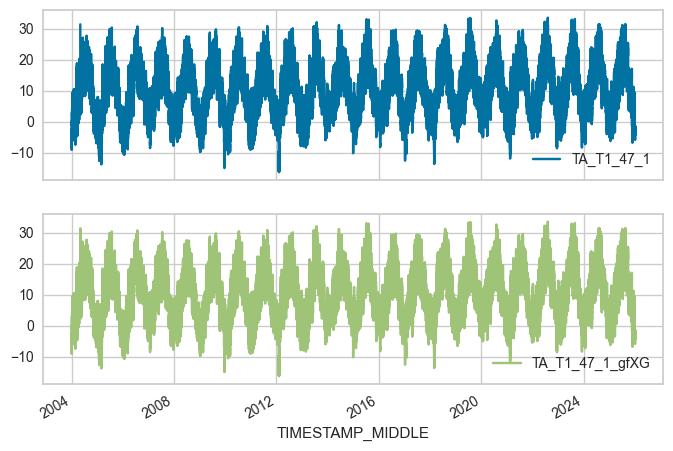

In [29]:
meteo6_2004_2025[[VAR, gapfilled.name]].plot(subplots=True, x_compat=True);

</br>

## PPFD_IN_T1_47_1

In [31]:
VAR = "PPFD_IN_T1_47_1"

In [32]:
_df = pd.DataFrame()
_df[VAR] = meteo6_2004_2025[[VAR]].copy()
_df['SW_IN_T1_47_1_gfXG'] = meteo6_2004_2025[['SW_IN_T1_47_1_gfXG']].copy()
_df['SW_IN_POT'] = potrad(timestamp_index=_df.index, lat=SITE_LAT, lon=SITE_LON, utc_offset=1)
_df

,PPFD_IN_T1_47_1,SW_IN_T1_47_1_gfXG,SW_IN_POT
TIMESTAMP_MIDDLE,,,
2004-01-01 00:15:00,NaN,0.0,0.0
2004-01-01 00:45:00,NaN,0.0,0.0
2004-01-01 01:15:00,NaN,0.0,0.0
2004-01-01 01:45:00,NaN,0.0,0.0
2004-01-01 02:15:00,NaN,0.0,0.0
...,...,...,...
2025-12-31 21:45:00,0.0,0.0,0.0
2025-12-31 22:15:00,0.0,0.0,0.0
2025-12-31 22:45:00,0.0,0.0,0.0


In [33]:
xgb = XGBoostTS(
    input_df=_df,
    target_col=VAR,
    perm_n_repeats=10,
    vectorize_timestamps=True,
    add_continuous_record_number=True,
    n_estimators=1000,
    random_state=42,
    early_stopping_rounds=50,
    n_jobs=-1
)


Adding new data columns ...
++ Added new columns with timestamp info: ['.YEAR', '.SEASON', '.SEASON_SIN', '.SEASON_COS', '.MONTH', '.MONTH_SIN', '.MONTH_COS', '.WEEK', '.WEEK_SIN', '.WEEK_COS', '.DOY', '.DOY_SIN', '.DOY_COS', '.HOUR', '.HOUR_SIN', '.HOUR_COS', '.YEARMONTH', '.YEARDOY', '.YEARWEEK'] 
++ Added new column .RECORDNUMBER with record numbers from 1 to 385728.


In [34]:
xgb.trainmodel(showplot_scores=False, showplot_importance=False)
xgb.report_traintest()


Training final model ...
>>> Training model <class 'xgboost.sklearn.XGBRegressor'> based on data between 2004-09-20 11:15:00 and 2025-12-31 23:15:00 ...
>>> Fitting model to training data ...
[0]	validation_0-rmse:343.29022	validation_1-rmse:342.70887
[1]	validation_0-rmse:243.79532	validation_1-rmse:243.52124
[2]	validation_0-rmse:175.39763	validation_1-rmse:175.31185
[3]	validation_0-rmse:129.02782	validation_1-rmse:129.02668
[4]	validation_0-rmse:98.49615	validation_1-rmse:98.51122
[5]	validation_0-rmse:79.18406	validation_1-rmse:79.16156
[6]	validation_0-rmse:67.50860	validation_1-rmse:67.44353
[7]	validation_0-rmse:60.74806	validation_1-rmse:60.64847
[8]	validation_0-rmse:57.04175	validation_1-rmse:56.89147
[9]	validation_0-rmse:55.05286	validation_1-rmse:54.88639
[10]	validation_0-rmse:53.73028	validation_1-rmse:53.61670
[11]	validation_0-rmse:53.12080	validation_1-rmse:52.99201
[12]	validation_0-rmse:52.65132	validation_1-rmse:52.56565
[13]	validation_0-rmse:52.22227	validation

In [35]:
xgb.fillgaps(showplot_scores=False, showplot_importance=False)
xgb.report_gapfilling()


Gap-filling using final model ...
>>> Using final model on all data to predict target PPFD_IN_T1_47_1 ...
>>> Using final model on all data to calculate permutation importance ...
>>> Calculating prediction scores based on all data predicting PPFD_IN_T1_47_1 ...
>>> Predicting target PPFD_IN_T1_47_1 where all features are available ... predicted 385728 records.
>>> Collecting results for final model ...
>>> Filling 13927 missing records in target with predictions from final model ...
>>> Storing gap-filled time series in variable PPFD_IN_T1_47_1_gfXG ...
>>> Restoring original timestamp in results ...

Gap-filling 0 remaining missing records in PPFD_IN_T1_47_1_gfXG using fallback model ...
>>> Fallback model not necessary, all gaps were already filled.
>>> Combining predictions from full model and fallback model ...

GAP-FILLING RESULTS

Model scores and feature importances were calculated from high-quality predicted targets (13927 values, PPFD_IN_T1_47_1_gfXG where flag=1) in compari

In [36]:
observed = _df[VAR]
gapfilled = xgb.get_gapfilled_target()
meteo6_2004_2025[gapfilled.name] = gapfilled

In [38]:
meteo6_2004_2025[[VAR, gapfilled.name]].describe()

,PPFD_IN_T1_47_1,PPFD_IN_T1_47_1_gfXG
count,371801.000000,385728.000000
mean,288.553170,290.806360
std,486.442862,488.153941
min,0.000000,-17.827450
25%,0.000000,0.000000
50%,0.000000,0.411981
75%,370.483220,375.782347
max,2270.612673,2270.612673


### Plot time series

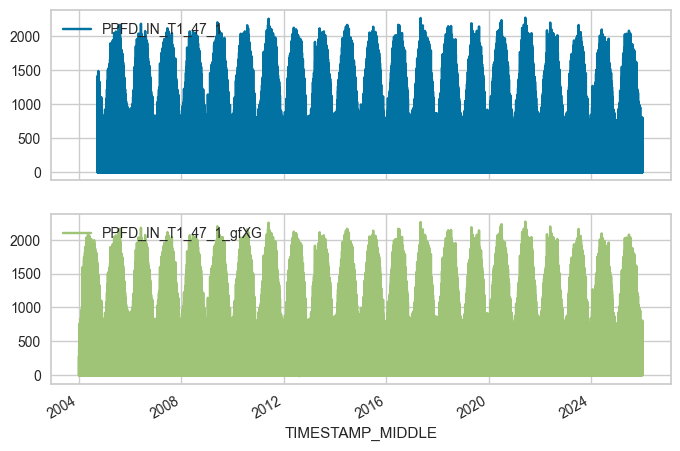

In [37]:
meteo6_2004_2025[[VAR, gapfilled.name]].plot(subplots=True, x_compat=True);

</br>

# Plot time series

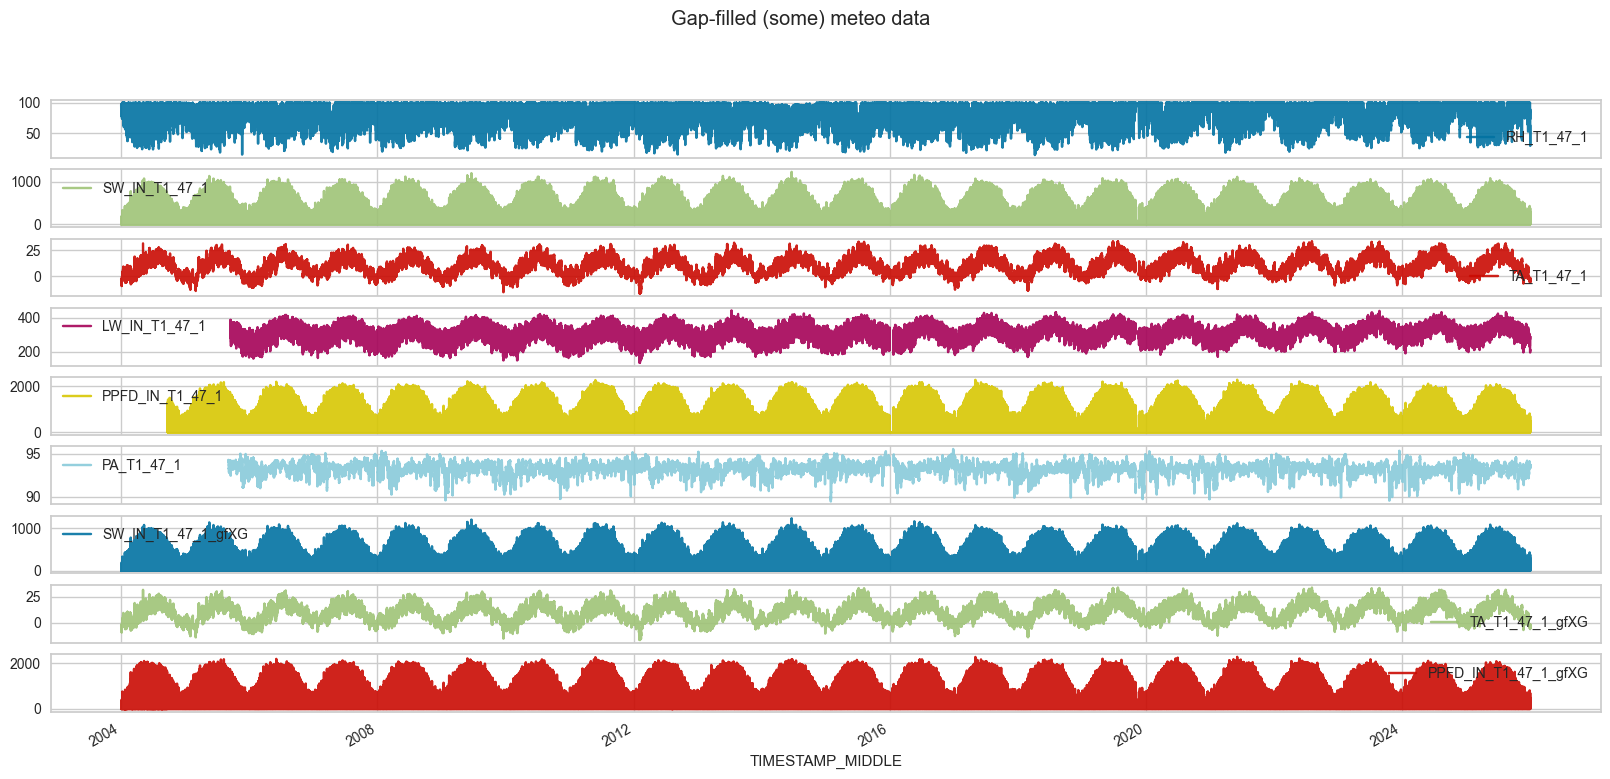

In [39]:
_plot_df = meteo6_2004_2025.copy()
_plot_df = _plot_df.replace(-9999, np.nan)
_plot_df.plot(subplots=True, figsize=(20, 9), title="Gap-filled (some) meteo data", alpha=.9, x_compat=True);

## Heatmaps

In [40]:
meteo6_2004_2025

,RH_T1_47_1,SW_IN_T1_47_1,TA_T1_47_1,LW_IN_T1_47_1,PPFD_IN_T1_47_1,PA_T1_47_1,SW_IN_T1_47_1_gfXG,TA_T1_47_1_gfXG,PPFD_IN_T1_47_1_gfXG
TIMESTAMP_MIDDLE,,,,,,,,,
2004-01-01 00:15:00,96.366667,0.0,-2.666667,NaN,NaN,NaN,0.0,-2.666667,-1.290524
2004-01-01 00:45:00,95.566667,0.0,-2.566667,NaN,NaN,NaN,0.0,-2.566667,-1.290524
2004-01-01 01:15:00,92.200000,0.0,-2.533333,NaN,NaN,NaN,0.0,-2.533333,0.203387
2004-01-01 01:45:00,91.300000,0.0,-2.633333,NaN,NaN,NaN,0.0,-2.633333,0.203387
2004-01-01 02:15:00,92.633333,0.0,-2.800000,NaN,NaN,NaN,0.0,-2.800000,0.238187
...,...,...,...,...,...,...,...,...,...
2025-12-31 21:45:00,42.332976,0.0,-3.081644,210.420480,0.0,93.435334,0.0,-3.081644,0.000000
2025-12-31 22:15:00,39.230344,0.0,-3.084372,210.648200,0.0,93.422110,0.0,-3.084372,0.000000
2025-12-31 22:45:00,55.771803,0.0,-3.423939,211.147057,0.0,93.404179,0.0,-3.423939,0.000000


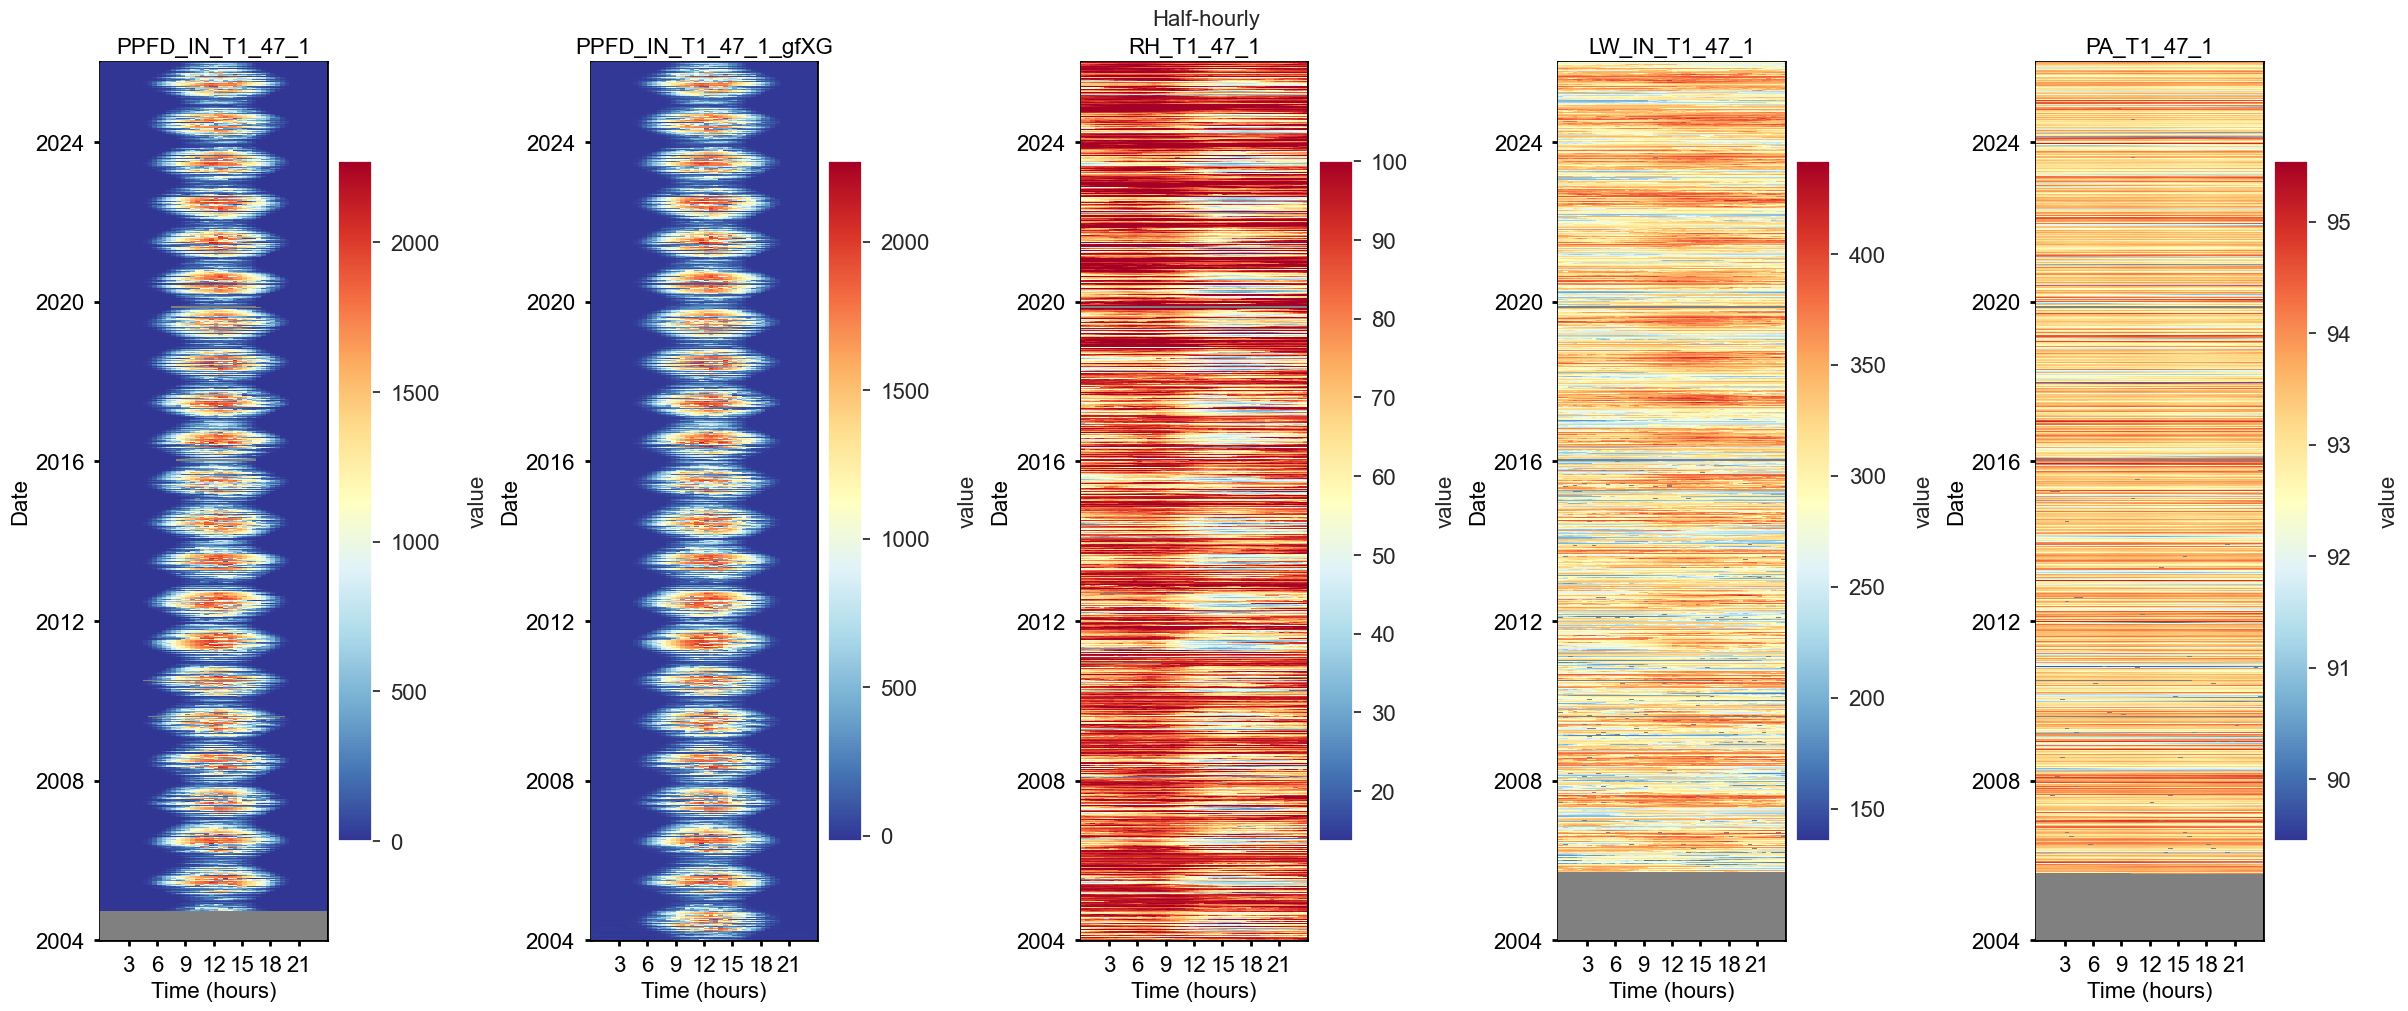

In [47]:
fig, axs = plt.subplots(ncols=5, figsize=(24, 10), dpi=100, layout="constrained")
fig.suptitle(f'Half-hourly', fontsize=16)
dv.heatmapdatetime(series=meteo6_2004_2025['PPFD_IN_T1_47_1'], title="PPFD_IN_T1_47_1", ax=axs[0], cb_digits_after_comma=0, zlabel="value").plot()
dv.heatmapdatetime(series=meteo6_2004_2025['PPFD_IN_T1_47_1_gfXG'], title="PPFD_IN_T1_47_1_gfXG", ax=axs[1], cb_digits_after_comma=0, zlabel="value").plot()
dv.heatmapdatetime(series=meteo6_2004_2025['RH_T1_47_1'], title="RH_T1_47_1", ax=axs[2], cb_digits_after_comma=0, zlabel="value").plot()
dv.heatmapdatetime(series=meteo6_2004_2025['LW_IN_T1_47_1'], title="LW_IN_T1_47_1", ax=axs[3], cb_digits_after_comma=0, zlabel="value").plot()
dv.heatmapdatetime(series=meteo6_2004_2025['PA_T1_47_1'], title="PA_T1_47_1", ax=axs[4], cb_digits_after_comma=0, zlabel="value").plot()

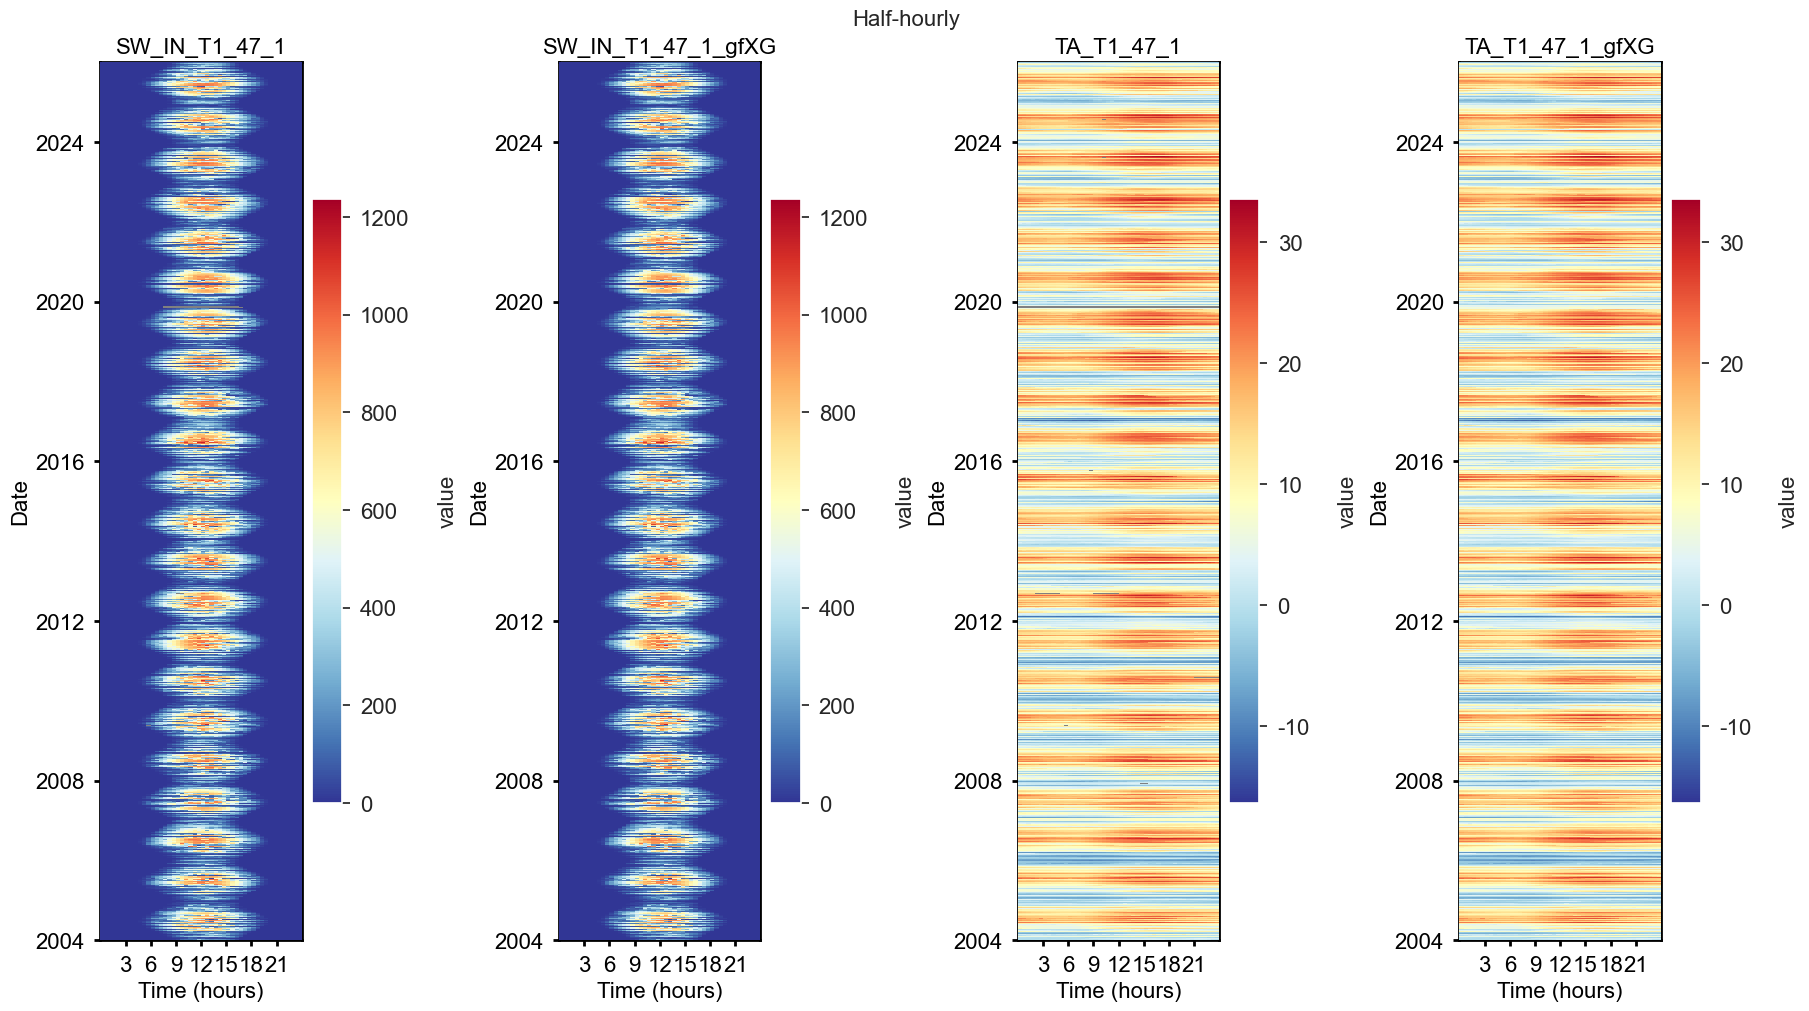

In [43]:
fig, axs = plt.subplots(ncols=4, figsize=(18, 10), dpi=100, layout="constrained")
fig.suptitle(f'Half-hourly', fontsize=16)
dv.heatmapdatetime(series=meteo6_2004_2025['SW_IN_T1_47_1'], title="SW_IN_T1_47_1", ax=axs[0], cb_digits_after_comma=0, zlabel="value").plot()
dv.heatmapdatetime(series=meteo6_2004_2025['SW_IN_T1_47_1_gfXG'], title="SW_IN_T1_47_1_gfXG", ax=axs[1], cb_digits_after_comma=0, zlabel="value").plot()
dv.heatmapdatetime(series=meteo6_2004_2025['TA_T1_47_1'], title="TA_T1_47_1", ax=axs[2], cb_digits_after_comma=0, zlabel="value").plot()
dv.heatmapdatetime(series=meteo6_2004_2025['TA_T1_47_1_gfXG'], title="TA_T1_47_1_gfXG", ax=axs[3], cb_digits_after_comma=0, zlabel="value").plot()

</br>

# Stats

In [48]:
meteo6_2004_2025.describe()

,RH_T1_47_1,SW_IN_T1_47_1,TA_T1_47_1,LW_IN_T1_47_1,PPFD_IN_T1_47_1,PA_T1_47_1,SW_IN_T1_47_1_gfXG,TA_T1_47_1_gfXG,PPFD_IN_T1_47_1_gfXG
count,384175.000000,385124.000000,384264.000000,352171.000000,371801.000000,353407.000000,385728.000000,385728.000000,385728.000000
mean,78.080751,142.734231,9.387278,310.622397,288.553170,93.231461,142.757436,9.383412,290.806360
std,18.478266,237.273570,8.020959,45.554221,486.442862,0.738367,237.223281,8.016721,488.153941
min,13.666667,0.000000,-16.366667,135.445129,0.000000,89.446007,0.000000,-16.366667,-17.827450
25%,64.733333,0.000000,3.139529,282.514256,0.000000,92.849526,0.000000,3.163146,0.000000
50%,81.600000,0.000000,9.385775,315.875107,0.000000,93.306000,0.000000,9.366667,0.411981
75%,94.733333,191.378154,15.366667,343.460725,370.483220,93.696730,191.409764,15.366667,375.782347
max,100.000000,1236.201961,33.558765,441.779694,2270.612673,95.543335,1236.201961,33.558765,2270.612673


</br>

# Save to file

In [49]:
OUTNAME = "12_METEO6_GAPFILLED_2004-2025"
OUTPATH = r""
filepath = save_parquet(filename=OUTNAME, data=meteo6_2004_2025, outpath=OUTPATH)
meteo6_2004_2025.to_csv(Path(OUTPATH) / f"{OUTNAME}.csv")

Saved file 12_METEO6_GAPFILLED_2004-2025.parquet (0.249 seconds).


</br>

# End of notebook.

In [50]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2026-01-14 16:49:32


</br>